In [1]:
%matplotlib inline
import torch
from torch.distributions import multinomial
from d2l import torch as d2l

In [4]:
fair_probs = torch.ones([6]) / 6
print(fair_probs)

# 这一行代码的作用是：创建一个多项分布对象，表示掷一次骰子的概率分布（fair_probs），然后从该分布中采样一次（即模拟一次掷骰子的结果）。
multinomial.Multinomial(1, fair_probs).sample()

tensor([0.1667, 0.1667, 0.1667, 0.1667, 0.1667, 0.1667])


tensor([1., 0., 0., 0., 0., 0.])

In [7]:
multinomial.Multinomial(10, fair_probs).sample()

tensor([4., 1., 2., 1., 2., 0.])

In [9]:
# 将结果存储为32位浮点数以进行除法
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts, counts / 1000  # 相对频率作为估计值

(tensor([175., 174., 168., 155., 165., 163.]),
 tensor([0.1750, 0.1740, 0.1680, 0.1550, 0.1650, 0.1630]))

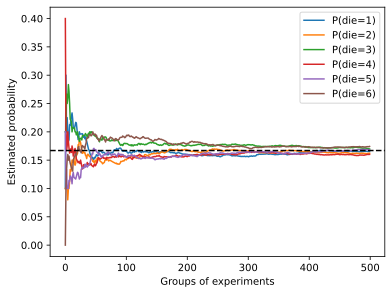

In [ ]:
#                              每组10个样本               500组
counts = multinomial.Multinomial(10, fair_probs).sample((500,))
# 计算每一组实验中每个面点数的累计出现次数（按组累加）
# cumsum函数用于对指定维度上的元素进行累加求和，即返回累计和。
# 这里dim=0表示按行累计（每一组实验的累计出现次数）。
cum_counts = counts.cumsum(dim=0)
# 计算每一组实验后各个点数出现的概率估计值（即累计出现次数除以累计总投掷次数）
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

# 设置绘图窗口的尺寸为6英寸 x 4.5英寸，方便显示图像
d2l.set_figsize((6, 4.5))
# 依次遍历骰子的6个面（i=0到5）
for i in range(6):
    # estimates[:, i] 取出第i个点数在所有实验组中的概率估计，
    # .numpy() 将Tensor转换为NumPy数组以便matplotlib处理，
    # d2l.plt.plot 绘制该点数概率随实验组数增长的曲线，
    # label 指定了图例中显示的标签，如"P(die=1)"等
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
# d2l.plt.axhline 在图中添加一条y=0.167的水平虚线，
# 0.167约等于1/6，代表硬币每个面理论上的概率，作为参考线
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
# d2l.plt.gca() 获取当前坐标轴对象，
# set_xlabel 设置x轴标签为'Groups of experiments'（实验组数）
d2l.plt.gca().set_xlabel('Groups of experiments')
# set_ylabel 设置y轴标签为'Estimated probability'（估计概率）
d2l.plt.gca().set_ylabel('Estimated probability')
# d2l.plt.legend() 显示图例，为每条概率曲线加上label说明
d2l.plt.legend();

### 2.6 TEST

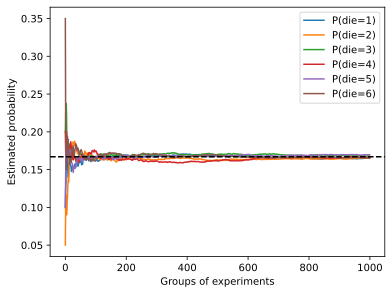

In [15]:
#                              每组10个样本               500组
counts = multinomial.Multinomial(20, fair_probs).sample((1000,))
# 计算每一组实验中每个面点数的累计出现次数（按组累加）
# cumsum函数用于对指定维度上的元素进行累加求和，即返回累计和。
# 这里dim=0表示按行累计（每一组实验的累计出现次数）。
cum_counts = counts.cumsum(dim=0)
# 计算每一组实验后各个点数出现的概率估计值（即累计出现次数除以累计总投掷次数）
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

# 设置绘图窗口的尺寸为6英寸 x 4.5英寸，方便显示图像
d2l.set_figsize((6, 4.5))
# 依次遍历骰子的6个面（i=0到5）
for i in range(6):
    # estimates[:, i] 取出第i个点数在所有实验组中的概率估计，
    # .numpy() 将Tensor转换为NumPy数组以便matplotlib处理，
    # d2l.plt.plot 绘制该点数概率随实验组数增长的曲线，
    # label 指定了图例中显示的标签，如"P(die=1)"等
    d2l.plt.plot(estimates[:, i].numpy(),
                 label=("P(die=" + str(i + 1) + ")"))
# d2l.plt.axhline 在图中添加一条y=0.167的水平虚线，
# 0.167约等于1/6，代表硬币每个面理论上的概率，作为参考线
d2l.plt.axhline(y=0.167, color='black', linestyle='dashed')
# d2l.plt.gca() 获取当前坐标轴对象，
# set_xlabel 设置x轴标签为'Groups of experiments'（实验组数）
d2l.plt.gca().set_xlabel('Groups of experiments')
# set_ylabel 设置y轴标签为'Estimated probability'（估计概率）
d2l.plt.gca().set_ylabel('Estimated probability')
# d2l.plt.legend() 显示图例，为每条概率曲线加上label说明
d2l.plt.legend();

已知P(A)=0.30, P(B)=0.40
P(A∪B)的取值范围：[0.40, 0.70]
P(A∩B)的取值范围：[0.00, 0.30]


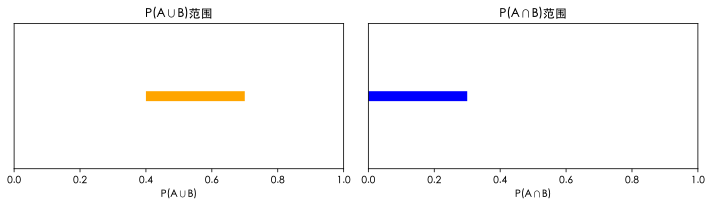

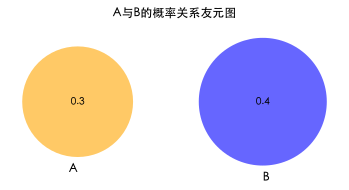

In [19]:
import numpy as np

# 两个事件A, B的概率
p_A = 0.3
p_B = 0.4

# A∪B 的概率上限和下限:
# 上限: min(1, p_A + p_B)
p_A_union_B_upper = min(1, p_A + p_B)
# 下限: max(p_A, p_B)
p_A_union_B_lower = max(p_A, p_B)

# A∩B 的概率上限和下限:
# 下限: max(0, p_A + p_B - 1)
p_A_intersect_B_lower = max(0, p_A + p_B - 1)
# 上限: min(p_A, p_B)
p_A_intersect_B_upper = min(p_A, p_B)

print("已知P(A)=%.2f, P(B)=%.2f" % (p_A, p_B))
print("P(A∪B)的取值范围：[%.2f, %.2f]" % (p_A_union_B_lower, p_A_union_B_upper))
print("P(A∩B)的取值范围：[%.2f, %.2f]" % (p_A_intersect_B_lower, p_A_intersect_B_upper))

# 可用可视化区间帮助理解
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang SC', 'STHeiti', 'Arial Unicode MS']  # macOS常用中文字体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

fig, axs = plt.subplots(1, 2, figsize=(10, 3))

# 可视化P(A∪B)范围
axs[0].hlines(1, p_A_union_B_lower, p_A_union_B_upper, colors='orange', linewidth=10)
axs[0].set_xlim(0, 1)
axs[0].set_title('P(A∪B)范围')
axs[0].set_xlabel('P(A∪B)')
axs[0].set_yticks([])

# 可视化P(A∩B)范围
axs[1].hlines(1, p_A_intersect_B_lower, p_A_intersect_B_upper, colors='blue', linewidth=10)
axs[1].set_xlim(0, 1)
axs[1].set_title('P(A∩B)范围')
axs[1].set_xlabel('P(A∩B)')
axs[1].set_yticks([])

plt.tight_layout()
plt.show()

# 用友元图（Venn Diagram）展示上述P(A), P(B), P(A∪B), P(A∩B)的情况
from matplotlib_venn import venn2

plt.figure(figsize=(6,6))
venn2(subsets = (p_A, p_B, 0), 
      set_labels = ('A', 'B'),
      set_colors=('orange', 'blue'),
      alpha = 0.6)

plt.title("A与B的概率关系友元图")
plt.show()